# Water Potability Prediction

Predict whether water is **potable (safe to drink)** from physicochemical measurements.

## Project objectives
- Perform exploratory data analysis (EDA).
- Identify and handle missing values and other data-quality issues.
- Analyze relationships between water-quality parameters and potability.
- Preprocess and prepare data for machine learning.
- Apply feature scaling and encoding where required.
- Train multiple classification algorithms.
- Compare models using Accuracy, Precision, Recall, F1-score and ROC-AUC.
- Identify the best-performing model.
- Analyze important features contributing to prediction.


In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import permutation_importance
import joblib

RANDOM_STATE = 42
DATA_PATH = "water_potability.csv"
sns.set_theme(style="whitegrid")


## 1. Load dataset

The dataset contains 9 numerical water-quality features and the binary `Potability` target.


In [2]:
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()
print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


## 2. Data-quality checks

We check column structure, data types, duplicates, missing values, target validity, non-finite values and suspicious pH values. Missing feature values are handled later inside the training pipeline to avoid data leakage.


In [3]:
target_col = "Potability"
feature_cols = [c for c in df.columns if c != target_col]

expected_features = ["ph", "Hardness", "Solids", "Chloramines", "Sulfate",
                     "Conductivity", "Organic_carbon", "Trihalomethanes", "Turbidity"]
missing_columns = [c for c in expected_features + [target_col] if c not in df.columns]
assert not missing_columns, f"Missing expected columns: {missing_columns}"

print("Data types:")
display(df.dtypes.to_frame("dtype"))
print("Duplicate rows:", df.duplicated().sum())
print("Target values:", sorted(df[target_col].dropna().unique().tolist()))
assert df[target_col].notna().all(), "Target contains missing values."
assert set(df[target_col].unique()).issubset({0, 1}), "Target must contain only 0 and 1."

missing_summary = pd.DataFrame({
    "missing_count": df[feature_cols].isna().sum(),
    "missing_percent": (df[feature_cols].isna().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)
display(missing_summary)

non_finite = {col: int((~np.isfinite(df[col].dropna())).sum()) for col in feature_cols}
display(pd.Series(non_finite, name="non_finite_count").to_frame())

if "ph" in df.columns:
    print("pH outside 0-14:", int(((df["ph"] < 0) | (df["ph"] > 14)).sum()))
    print("pH equal to 0:", int((df["ph"] == 0).sum()))


Data types:


,dtype
ph,float64
Hardness,float64
Solids,float64
Chloramines,float64
Sulfate,float64
Conductivity,float64
Organic_carbon,float64
Trihalomethanes,float64
Turbidity,float64
Potability,int64


Duplicate rows: 0
Target values: [0, 1]


,missing_count,missing_percent
Sulfate,781,23.84
ph,491,14.99
Trihalomethanes,162,4.95
Solids,0,0.00
Hardness,0,0.00
Chloramines,0,0.00
Conductivity,0,0.00
Organic_carbon,0,0.00
Turbidity,0,0.00


,non_finite_count
ph,0
Hardness,0
Solids,0
Chloramines,0
Sulfate,0
Conductivity,0
Organic_carbon,0
Trihalomethanes,0
Turbidity,0


pH outside 0-14: 0
pH equal to 0: 1


### Cleaning decision

Exact duplicate rows are removed if present. Invalid target rows would be removed rather than imputed, but the target is expected to be binary. Feature missingness is retained until the ML pipeline, where median imputation is learned from the training folds only.


In [4]:
duplicate_count = int(df.duplicated().sum())
if duplicate_count:
    df = df.drop_duplicates().reset_index(drop=True)

print("Shape after duplicate handling:", df.shape)


Shape after duplicate handling: (3276, 10)


## 3. Exploratory Data Analysis (EDA)

### 3.1 Descriptive statistics and class balance


,count,mean,std,min,25%,50%,75%,max
ph,2785.0,7.080795,1.594320,0.000000,6.093092,7.036752,8.062066,14.000000
Hardness,3276.0,196.369496,32.879761,47.432000,176.850538,196.967627,216.667456,323.124000
Solids,3276.0,22014.092526,8768.570828,320.942611,15666.690297,20927.833607,27332.762127,61227.196008
Chloramines,3276.0,7.122277,1.583085,0.352000,6.127421,7.130299,8.114887,13.127000
Sulfate,2495.0,333.775777,41.416840,129.000000,307.699498,333.073546,359.950170,481.030642
Conductivity,3276.0,426.205111,80.824064,181.483754,365.734414,421.884968,481.792304,753.342620
Organic_carbon,3276.0,14.284970,3.308162,2.200000,12.065801,14.218338,16.557652,28.300000
Trihalomethanes,3114.0,66.396293,16.175008,0.738000,55.844536,66.622485,77.337473,124.000000
Turbidity,3276.0,3.966786,0.780382,1.450000,3.439711,3.955028,4.500320,6.739000
Potability,3276.0,0.390110,0.487849,0.000000,0.000000,0.000000,1.000000,1.000000


,count,percentage
Potability,,
0,1998,60.99
1,1278,39.01


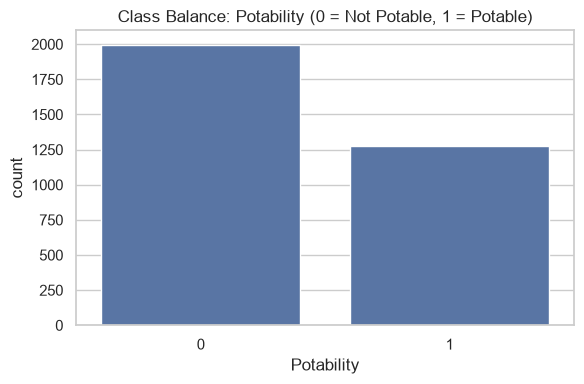

In [5]:
display(df[feature_cols + [target_col]].describe().T)

class_summary = df[target_col].value_counts().sort_index().to_frame("count")
class_summary["percentage"] = (class_summary["count"] / len(df) * 100).round(2)
display(class_summary)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col)
plt.title("Class Balance: Potability (0 = Not Potable, 1 = Potable)")
plt.tight_layout()
plt.show()


### 3.2 Feature distributions

Histograms and skewness values help identify scale differences and right-skewed variables.


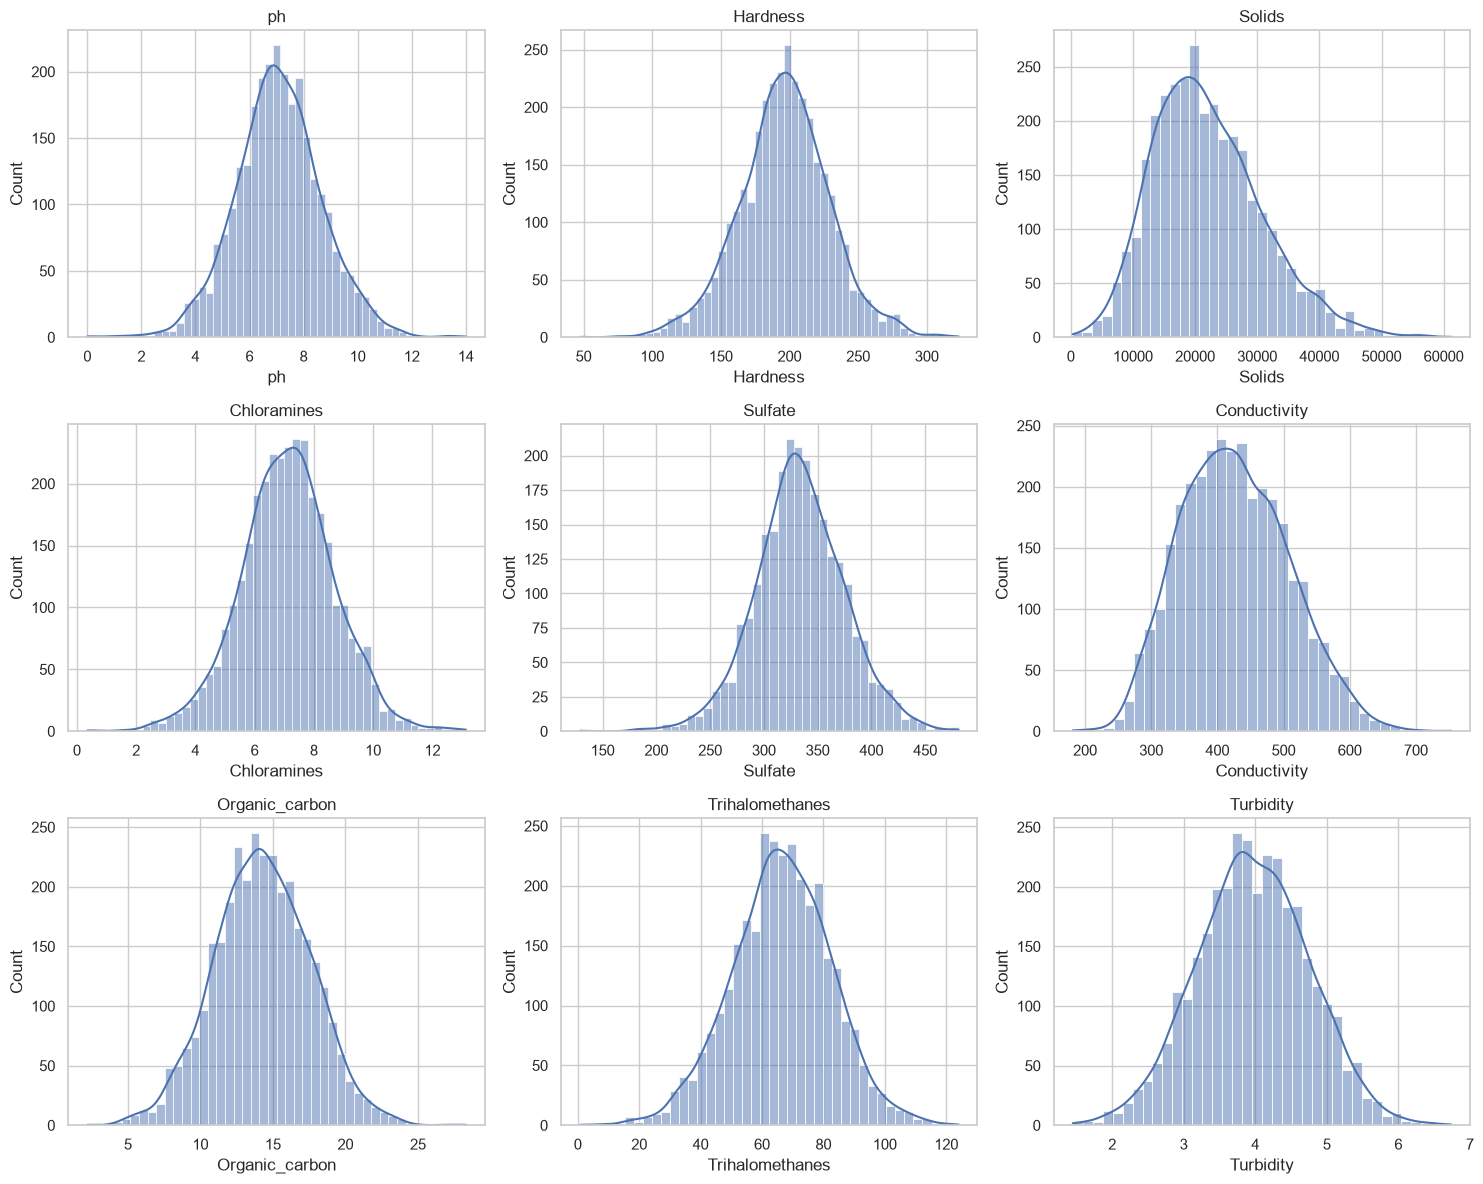

,skewness
Solids,0.621634
Conductivity,0.264490
ph,0.025630
Organic_carbon,0.025533
Turbidity,-0.007817
Chloramines,-0.012098
Sulfate,-0.035947
Hardness,-0.039342
Trihalomethanes,-0.083031


In [6]:
ncols = 3
nrows = int(np.ceil(len(feature_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = np.asarray(axes).ravel()
for ax, col in zip(axes, feature_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
for ax in axes[len(feature_cols):]:
    ax.remove()
plt.tight_layout()
plt.show()

display(df[feature_cols].skew().sort_values(ascending=False).to_frame("skewness"))


### 3.3 Relationships with potability

Correlation with the binary target is a first diagnostic. Boxplots show whether feature distributions differ between the two classes. Correlation is not a measure of causation and may miss non-linear relationships.


,correlation_with_potability
Solids,0.033743
Organic_carbon,-0.030001
Chloramines,0.023779
Sulfate,-0.023577
Hardness,-0.013837
Conductivity,-0.008128
Trihalomethanes,0.007130
ph,-0.003556
Turbidity,0.001581


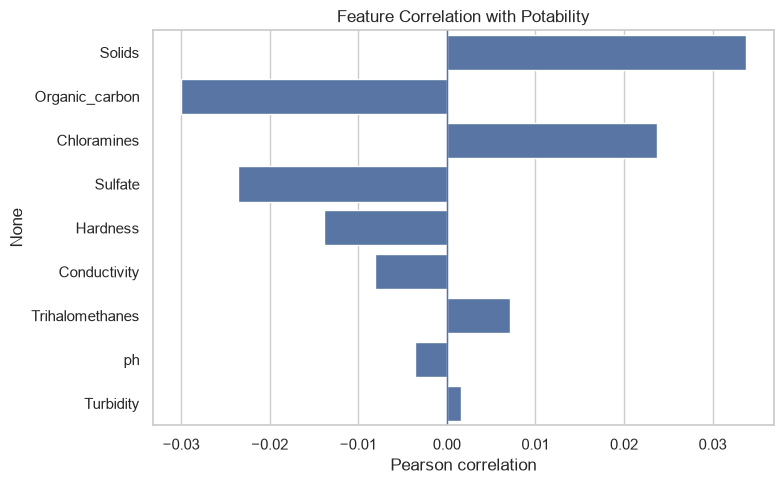

In [7]:
target_corr = (df[feature_cols + [target_col]].corr(numeric_only=True)[target_col]
               .drop(target_col).sort_values(key=np.abs, ascending=False))
display(target_corr.to_frame("correlation_with_potability"))

plt.figure(figsize=(8, 5))
sns.barplot(x=target_corr.values, y=target_corr.index)
plt.axvline(0, linewidth=1)
plt.title("Feature Correlation with Potability")
plt.xlabel("Pearson correlation")
plt.tight_layout()
plt.show()


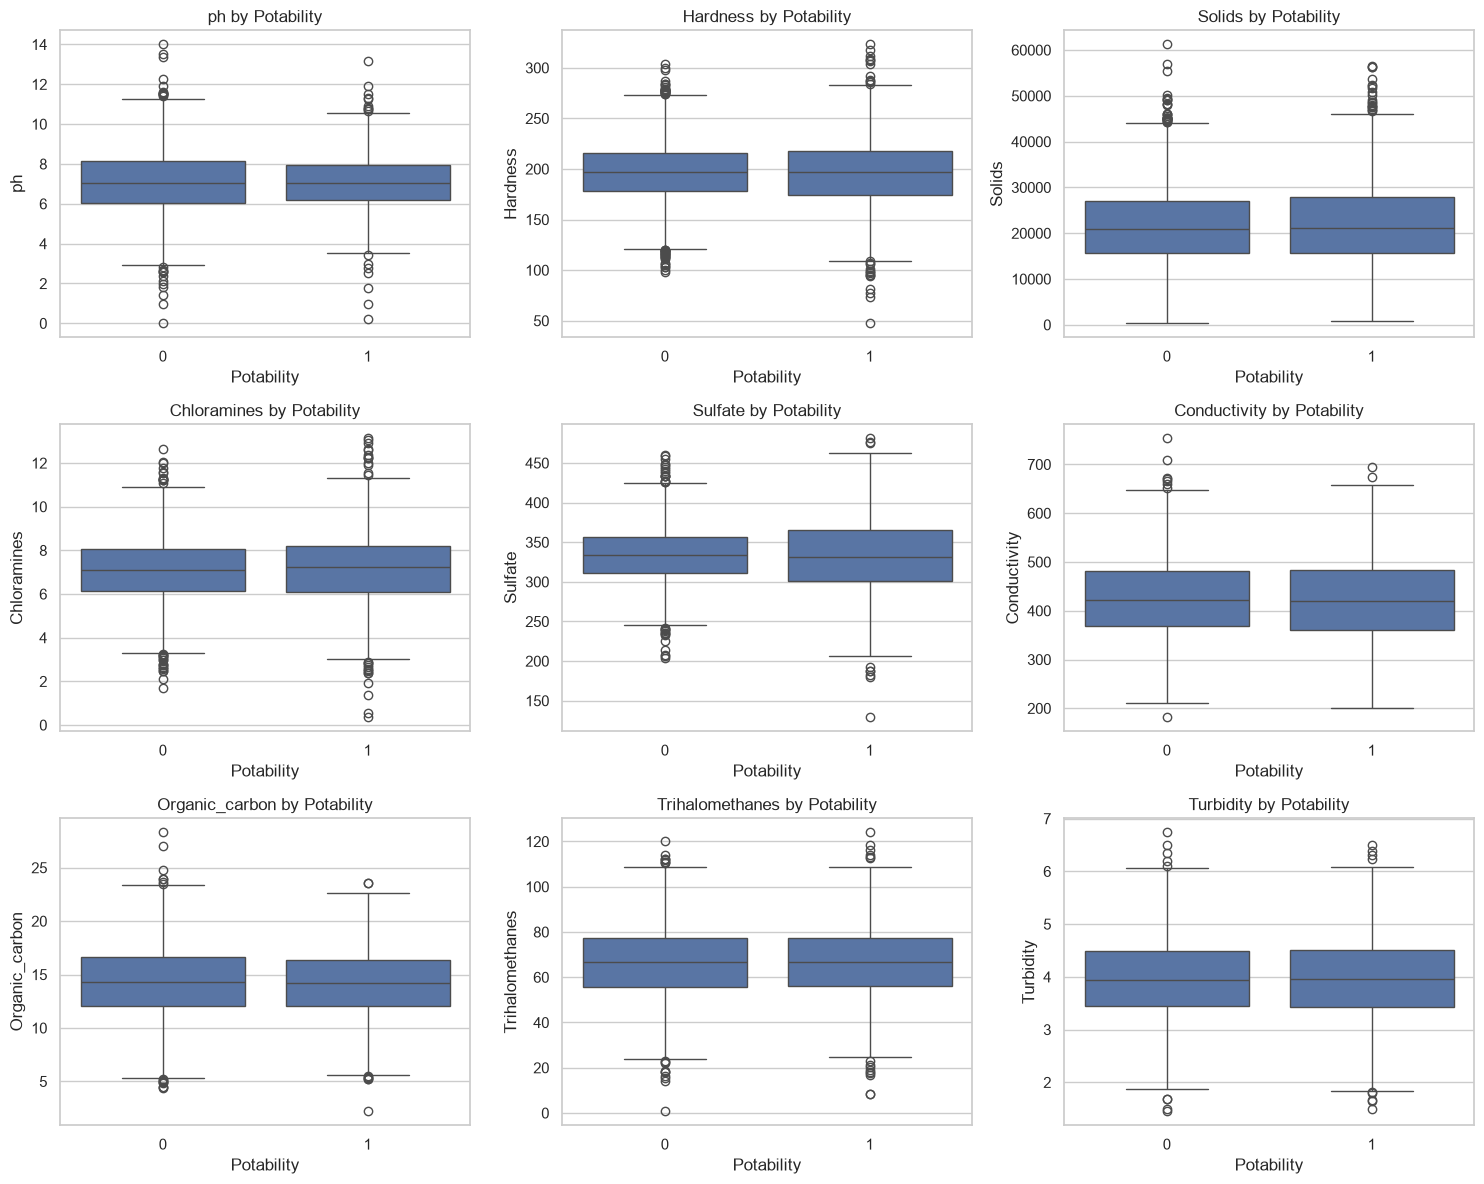

In [8]:
ncols = 3
nrows = int(np.ceil(len(feature_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = np.asarray(axes).ravel()
for ax, col in zip(axes, feature_cols):
    sns.boxplot(data=df, x=target_col, y=col, ax=ax)
    ax.set_title(f"{col} by Potability")
for ax in axes[len(feature_cols):]:
    ax.remove()
plt.tight_layout()
plt.show()


### 3.4 Feature-to-feature correlation


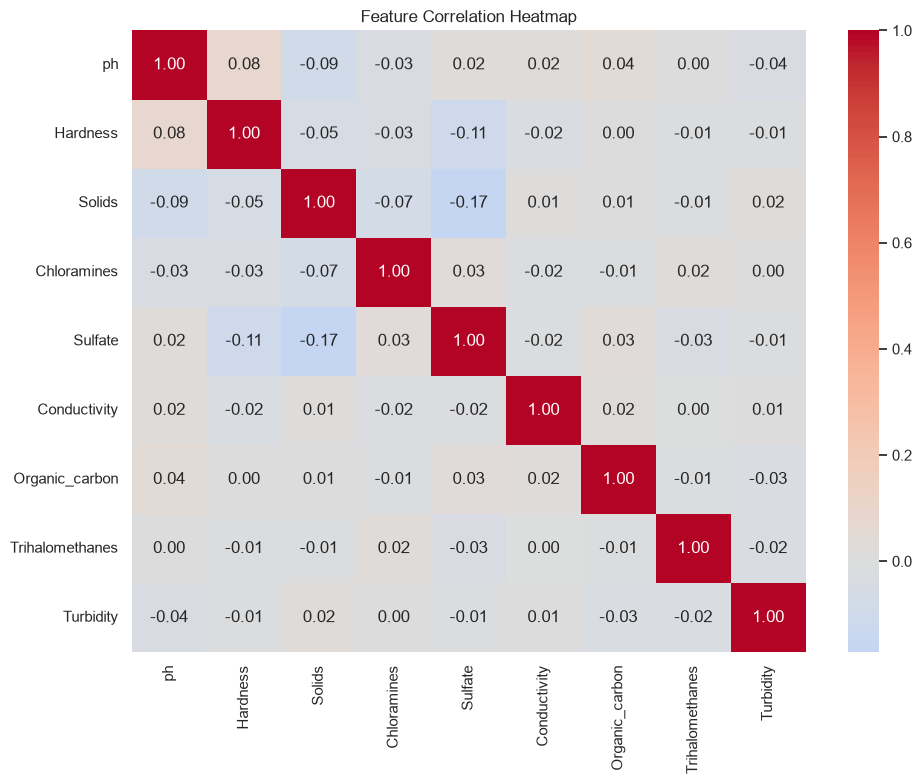

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[feature_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


## 4. Feature engineering

For skewed positive measurements, `log1p` versions are added. A conductivity × hardness interaction is also created. These operations are deterministic and do not learn statistics from the test set.


In [11]:
def add_features(data):
    data = data.copy()
    for col in ["Solids", "Organic_carbon", "Trihalomethanes", "Turbidity"]:
        if col in data.columns:
            data[f"{col}_log1p"] = np.log1p(data[col].clip(lower=0))
    if "Conductivity" in data.columns and "Hardness" in data.columns:
        data["Conductivity_x_Hardness"] = data["Conductivity"] * data["Hardness"]
    return data

X = add_features(df[feature_cols])
y = df[target_col].astype(int)
feature_cols_fe = list(X.columns)
print("Original features:", len(feature_cols))
print("Model features after engineering:", len(feature_cols_fe))
print("Engineered features:", [c for c in feature_cols_fe if c not in feature_cols])


Original features: 9
Model features after engineering: 14
Engineered features: ['Solids_log1p', 'Organic_carbon_log1p', 'Trihalomethanes_log1p', 'Turbidity_log1p', 'Conductivity_x_Hardness']


## 5. Train/test split and preprocessing

The test set is kept untouched until final evaluation. All predictors are numerical, so categorical encoding is not required. Standard scaling is important for Logistic Regression, SVM and KNN; a common preprocessing pipeline is used for reproducibility.


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape)
print("Test:", X_test.shape)

preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

def make_pipeline(model):
    return Pipeline([("preprocess", preprocess), ("model", model)])


Train: (2620, 14)
Test: (656, 14)


## 6. Baseline and multiple classification models

We compare six classifiers: Logistic Regression, Random Forest, Gradient Boosting, SVM (RBF), KNN and Gaussian Naive Bayes.


In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "Gaussian Naive Bayes": GaussianNB(),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for name, model in models.items():
    pipe = make_pipeline(model)
    scores = cross_validate(
        pipe, X_train, y_train, cv=cv, n_jobs=-1,
        scoring={"accuracy":"accuracy", "precision":"precision", "recall":"recall",
                 "f1":"f1", "roc_auc":"roc_auc"}
    )
    rows.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

comparison = pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
display(comparison.round(4))


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,SVM (RBF),0.6718,0.7101,0.2681,0.3887,0.6848
1,Random Forest,0.6641,0.6442,0.3102,0.4174,0.6635
2,KNN,0.6412,0.5932,0.2612,0.3622,0.6357
3,Gradient Boosting,0.6458,0.6074,0.2554,0.3585,0.6345
4,Gaussian Naive Bayes,0.6126,0.5076,0.2544,0.3384,0.5768
5,Logistic Regression,0.6088,0.5233,0.0078,0.0154,0.4781


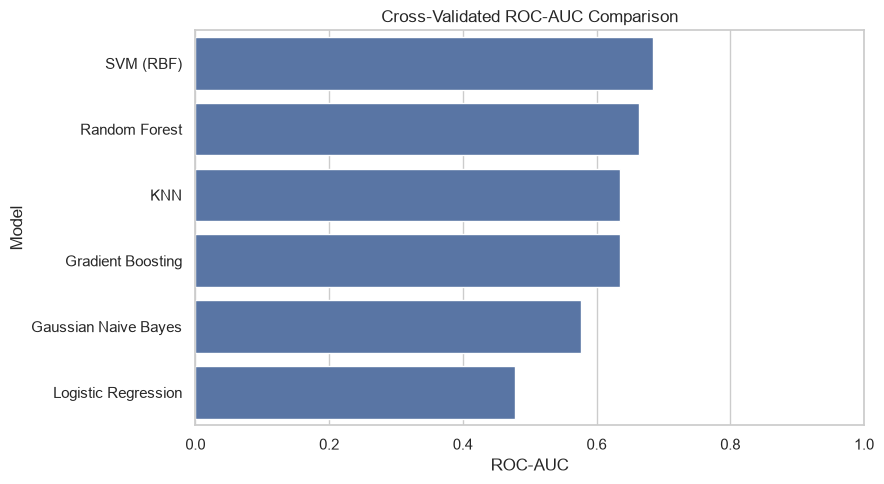

In [14]:
plt.figure(figsize=(9, 5))
sns.barplot(data=comparison, x="ROC-AUC", y="Model")
plt.xlim(0, 1)
plt.title("Cross-Validated ROC-AUC Comparison")
plt.tight_layout()
plt.show()


## 7. Hyperparameter tuning and model selection

Grid search is performed on the training data only. ROC-AUC is the primary selection metric because the classes are moderately imbalanced; F1-score is also reported. The final test set is not used to choose the model.


In [15]:
param_grids = {
    "Logistic Regression": {
        "model__C": [0.1, 1, 10],
        "model__class_weight": [None, "balanced"]
    },
    "Random Forest": {
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_leaf": [1, 2],
        "model__class_weight": [None, "balanced"]
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [2, 3]
    },
    "SVM (RBF)": {
        "model__C": [0.5, 1, 2],
        "model__gamma": ["scale", 0.1],
        "model__class_weight": [None, "balanced"]
    },
    "KNN": {
        "model__n_neighbors": [5, 11, 21],
        "model__weights": ["uniform", "distance"]
    },
    "Gaussian Naive Bayes": {
        "model__var_smoothing": [1e-9, 1e-8, 1e-7]
    }
}

tuned = {}
tuning_rows = []
for name, model in models.items():
    search = GridSearchCV(
        make_pipeline(model), param_grids[name], scoring="roc_auc",
        cv=cv, n_jobs=-1, refit=True
    )
    print(f"Tuning {name}...")
    search.fit(X_train, y_train)
    tuned[name] = search.best_estimator_
    tuning_rows.append({
        "Model": name,
        "Best CV ROC-AUC": search.best_score_,
        "Best Parameters": search.best_params_
    })

tuning_results = pd.DataFrame(tuning_rows).sort_values("Best CV ROC-AUC", ascending=False).reset_index(drop=True)
display(tuning_results.round(4))

best_model_name = tuning_results.loc[0, "Model"]
best_pipe = tuned[best_model_name]
best_cv_roc_auc = tuning_results.loc[0, "Best CV ROC-AUC"]
print("Selected model:", best_model_name)
print("Mean training CV ROC-AUC:", round(best_cv_roc_auc, 4))


Tuning Logistic Regression...
Tuning Random Forest...
Tuning Gradient Boosting...
Tuning SVM (RBF)...
Tuning KNN...
Tuning Gaussian Naive Bayes...


,Model,Best CV ROC-AUC,Best Parameters
0,SVM (RBF),0.6903,"{'model__C': 2, 'model__class_weight': 'balanc..."
1,Random Forest,0.6699,"{'model__class_weight': 'balanced', 'model__ma..."
2,KNN,0.6473,"{'model__n_neighbors': 21, 'model__weights': '..."
3,Gradient Boosting,0.6373,"{'model__learning_rate': 0.1, 'model__max_dept..."
4,Gaussian Naive Bayes,0.5768,{'model__var_smoothing': 1e-09}
5,Logistic Regression,0.4784,"{'model__C': 10, 'model__class_weight': None}"


Selected model: SVM (RBF)
Mean training CV ROC-AUC: 0.6903


## 8. Final test-set evaluation

The selected model is now evaluated once on the untouched test set using Accuracy, Precision, Recall, F1-score and ROC-AUC.


In [16]:
y_pred = best_pipe.predict(X_test)
y_score = best_pipe.predict_proba(X_test)[:, 1] if hasattr(best_pipe, "predict_proba") else best_pipe.decision_function(X_test)

final_metrics = pd.DataFrame([{
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_score)
}], index=[best_model_name])
display(final_metrics.round(4))
print(classification_report(y_test, y_pred, target_names=["Not Potable", "Potable"], zero_division=0))


,Accuracy,Precision,Recall,F1,ROC-AUC
SVM (RBF),0.6235,0.5179,0.5078,0.5128,0.6459


              precision    recall  f1-score   support

 Not Potable       0.69      0.70      0.69       400
     Potable       0.52      0.51      0.51       256

    accuracy                           0.62       656
   macro avg       0.60      0.60      0.60       656
weighted avg       0.62      0.62      0.62       656



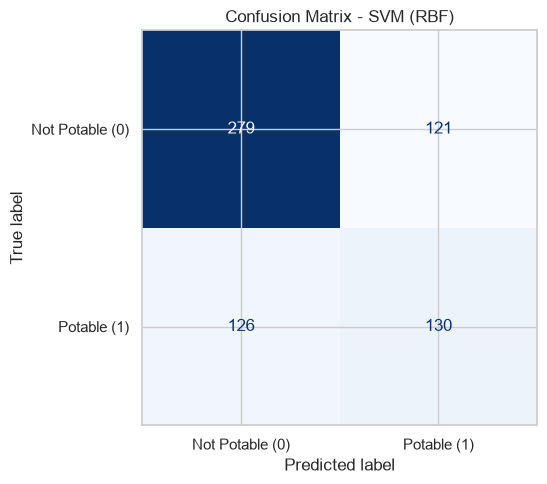

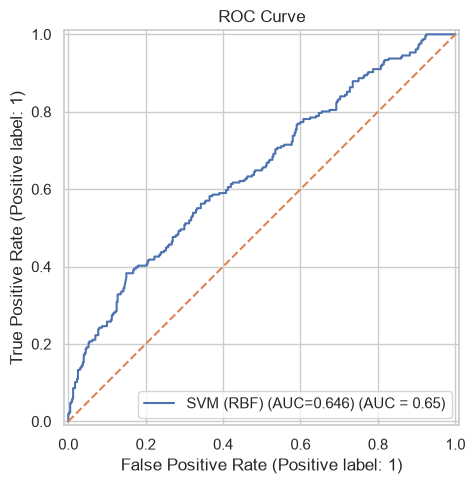

In [17]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["Not Potable (0)", "Potable (1)"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_score, name=f"{best_model_name} (AUC={final_metrics.iloc[0]['ROC-AUC']:.3f})", ax=ax)
ax.plot([0, 1], [0, 1], "--", label="Random classifier")
ax.set_title("ROC Curve")
plt.tight_layout()
plt.show()


## 9. Feature importance

Permutation importance measures the change in ROC-AUC when a feature is randomly shuffled. It is a predictive importance measure, not evidence of causation.


,Feature,Importance,Std
0,ph,0.0817,0.0121
1,Sulfate,0.0775,0.0119
2,Chloramines,0.0286,0.0092
3,Hardness,0.0257,0.0067
4,Solids,0.0226,0.0079
5,Solids_log1p,0.0144,0.0062
6,Organic_carbon,0.0070,0.0060
7,Organic_carbon_log1p,0.0055,0.0048
8,Conductivity,0.0010,0.0084
9,Conductivity_x_Hardness,0.0003,0.0063


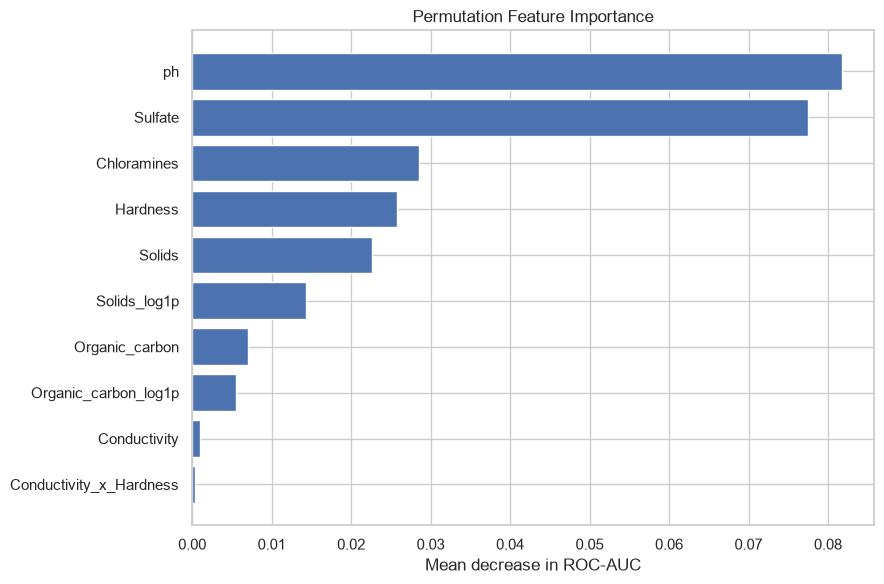

In [18]:
perm = permutation_importance(
    best_pipe, X_test, y_test, scoring="roc_auc",
    n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1
)
importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm.importances_mean,
    "Std": perm.importances_std
}).sort_values("Importance", ascending=False).reset_index(drop=True)

display(importance_df.round(4))

plot_df = importance_df.head(10).sort_values("Importance")
plt.figure(figsize=(9, 6))
plt.barh(plot_df["Feature"], plot_df["Importance"])
plt.xlabel("Mean decrease in ROC-AUC")
plt.title("Permutation Feature Importance")
plt.tight_layout()
plt.show()


## 10. Prediction examples and model persistence


In [19]:
examples = X_test.sample(5, random_state=RANDOM_STATE)
example_pred = best_pipe.predict(examples)
example_prob = best_pipe.predict_proba(examples)[:, 1] if hasattr(best_pipe, "predict_proba") else best_pipe.decision_function(examples)

prediction_output = examples.copy()
prediction_output["Predicted_Potability"] = example_pred
prediction_output["Potability_Probability"] = example_prob
display(prediction_output.round(4))

MODEL_PATH = "water_potability_model.joblib"
joblib.dump(best_pipe, MODEL_PATH)
print(f"Saved model pipeline to: {MODEL_PATH}")

loaded_model = joblib.load(MODEL_PATH)
print("Saved-model predictions match:", np.array_equal(y_pred, loaded_model.predict(X_test)))


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Solids_log1p,Organic_carbon_log1p,Trihalomethanes_log1p,Turbidity_log1p,Conductivity_x_Hardness,Predicted_Potability,Potability_Probability
2295,NaN,172.1115,26595.3735,8.2323,NaN,348.8436,7.8777,93.3028,3.5503,10.1885,2.1835,4.5465,1.5152,60039.9959,0,0.3283
632,NaN,181.3747,14579.8221,5.4351,NaN,308.7925,9.5451,60.2146,4.1617,9.5875,2.3557,4.1144,1.6413,56007.1347,1,0.5968
2243,6.0145,205.4829,23268.2431,9.0358,283.3404,371.4035,16.8637,73.0178,2.6861,10.0549,2.8828,4.3043,1.3046,76317.0779,0,0.3892
2869,7.1712,199.1602,13163.0313,5.7625,351.2781,436.6024,19.1032,52.5775,2.2091,9.4852,3.0009,3.9811,1.1660,86953.8177,1,0.4617
3113,7.7346,230.9195,21776.5945,6.9086,NaN,395.1150,15.0336,92.6974,3.8215,9.9886,2.7747,4.5401,1.5731,91239.7516,0,0.3907


Saved model pipeline to: water_potability_model.joblib
Saved-model predictions match: True


## 11. Conclusion

This notebook now covers all requested objectives: EDA, data-quality checks, missing-value handling, relationship analysis, preprocessing and scaling, multiple classifiers, metric comparison, cross-validated hyperparameter tuning, best-model selection, final test evaluation, feature importance, prediction examples and model persistence.

**Important:** the best model and final metric values are produced when the notebook is executed with the project dataset; they are not hard-coded.
